# 03 — Market Maker Inventory & Liquidity Withdrawal

In Notebook 01, we explained price formation.
In Notebook 02, we studied liquidity and market depth.

In this notebook, we analyze:

- Inventory-based market making
- Spread adjustment under volatility
- Inventory drift under order imbalance
- Liquidity withdrawal when risk limit is breached

Mục tiêu của notebook này là trả lời câu hỏi:

1. Thanh khoản đến từ đâu?
2. Và khi nào thanh khoản biến mất?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.structure import MarketMaker

## Inventory-Based Market Making

Market maker trong mô hình này hoạt động theo 3 cơ chế chính:

1. Spread tăng theo volatility
2. Giá bid/ask bị skew theo inventory
3. Nếu inventory vượt giới hạn → market maker rút khỏi thị trường

Cơ chế này mô phỏng rủi ro tồn kho (inventory risk).

Nếu dòng lệnh một chiều quá mạnh, market maker sẽ tích tụ vị thế và có thể buộc phải ngừng cung cấp thanh khoản.

## Simulation 1 — One-Sided Order Flow

Giả sử thị trường có áp lực mua liên tục.

Client luôn mua từ market maker.
Market maker sẽ bán ra và inventory trở nên âm (short).

Chúng ta quan sát:

- Inventory drift
- Thời điểm liquidity withdrawal

In [2]:
np.random.seed(42)

mm = MarketMaker(
    base_spread=0.001,
    inventory_limit=500,
    risk_aversion=0.8,
    volatility_sensitivity=5.0,
)

mid_price = 100
volatility = 0.01

inventory_path = []
active_path = []

for t in range(300):

    quotes = mm.quote(mid_price, volatility)

    if not mm.active:
        break

    trade_price = quotes["ask"]

    # Client luôn mua
    mm.execute_trade(trade_price, quantity=10, side="buy")

    inventory_path.append(mm.inventory)
    active_path.append(mm.active)

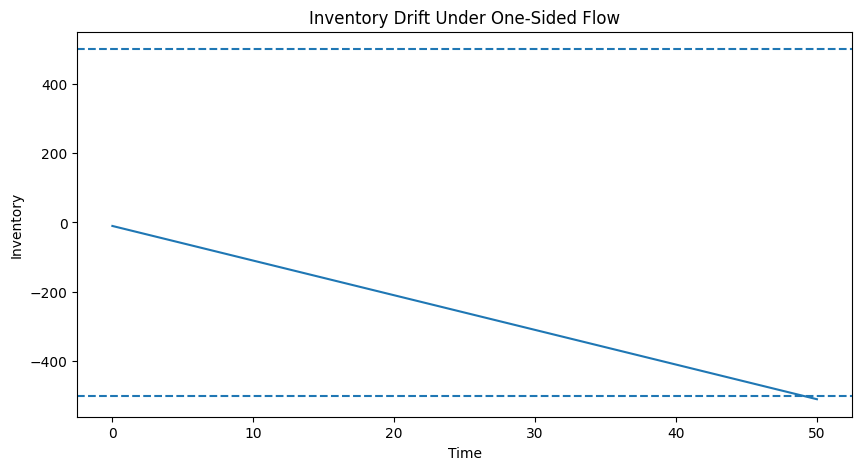

In [3]:
plt.figure(figsize=(10,5))
plt.plot(inventory_path)
plt.axhline(mm.inventory_limit, linestyle="--")
plt.axhline(-mm.inventory_limit, linestyle="--")
plt.title("Inventory Drift Under One-Sided Flow")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.show()

## Interpretation — Deterministic Inventory Drift and Structural Implications

Biểu đồ cho thấy inventory giảm gần như tuyến tính theo thời gian.
Điều này không phải là hiện tượng ngẫu nhiên, mà là hệ quả tất yếu của cơ chế sau:

1) Order flow một chiều
   Client liên tục mua từ market maker.
   Mỗi giao dịch làm market maker bán ra một lượng cố định.
   Inventory do đó giảm đều theo từng bước.

2) Không có cơ chế mean-reversion
   Trong mô hình hiện tại:
   - Không có lực cân bằng inventory
   - Không có arbitrageur trung gian
   - Không có flow hai chiều

   Vì vậy inventory trở thành một quá trình tích lũy rủi ro đơn điệu.

3) Tính tuyến tính của drift
   Vì mỗi bước giảm cùng một lượng (10 units), inventory giảm với slope hằng số.
   Đây là một hệ thống deterministic under asymmetric flow.

---

### Economic Meaning of the Boundaries

Hai đường ngang đứt nét biểu diễn inventory limit.

Inventory limit không chỉ là một tham số kỹ thuật.
Nó đại diện cho:

- Capital constraint
- Risk tolerance
- VaR constraint nội bộ
- Balance sheet capacity

Khi inventory chạm giới hạn này:

> Market maker không còn đủ khả năng chịu thêm rủi ro directional.

Việc withdrawal xảy ra không phải do "thiếu người giao dịch",
mà do constraint nội tại của người cung cấp thanh khoản.

---

### Structural Insight

Liquidity không phải là một biến ngoại sinh.

Liquidity phụ thuộc vào:

> Risk-bearing capacity of intermediaries.

Trong mô hình này, khi:

> |Inventory| → Inventory limit

thì:

> Liquidity → 0 (vì market maker inactive)

Điều này hàm ý:

Liquidity là một trạng thái điều kiện (conditional state),
không phải một đại lượng cố định.

---

### Hidden Fragility

Hệ thống nhìn có vẻ ổn định cho đến khi chạm boundary.

Từ t = 0 đến gần inventory limit:

- Spread vẫn nhỏ
- Quotes vẫn tồn tại
- Market hoạt động bình thường

Nhưng rủi ro đang tích tụ một cách âm thầm.

Đây là một ví dụ của:

> Latent structural fragility.

Hệ thống có thể chuyển từ trạng thái "thanh khoản dồi dào"
sang "không có thanh khoản"
chỉ trong một bước thời gian.

---

### Microstructure Perspective

Inventory risk là chi phí trung gian tài chính phải chịu.

Market maker đóng vai trò:

> Shock absorber

Nhưng shock absorber có giới hạn hấp thụ.

Khi absorber đầy:

> Shock truyền thẳng vào giá.

Đây chính là cầu nối logic sang liquidation cascade trong notebook sau.

---

### Theoretical Extension

Nếu ta thêm:

- Volatility feedback
- Mark-to-market PnL stress
- Capital erosion

thì inventory limit sẽ không còn là một ngưỡng cứng,
mà sẽ co lại theo thời gian.

Điều đó sẽ làm hệ thống dễ vỡ hơn nữa.

---

### Core Concept to Remember

Inventory drift dưới order flow một chiều là cơ chế tích tụ rủi ro nội sinh.

Liquidity withdrawal không phải là một sự kiện ngoại lai.

Nó là kết quả tất yếu của:

> Directional pressure + Finite balance sheet.

## Simulation 2 — Spread Expansion Under Volatility

Khi volatility tăng:

- Adverse selection risk tăng
- Market maker widen spread để bù đắp rủi ro

Chúng ta kiểm tra quan hệ giữa volatility và spread.

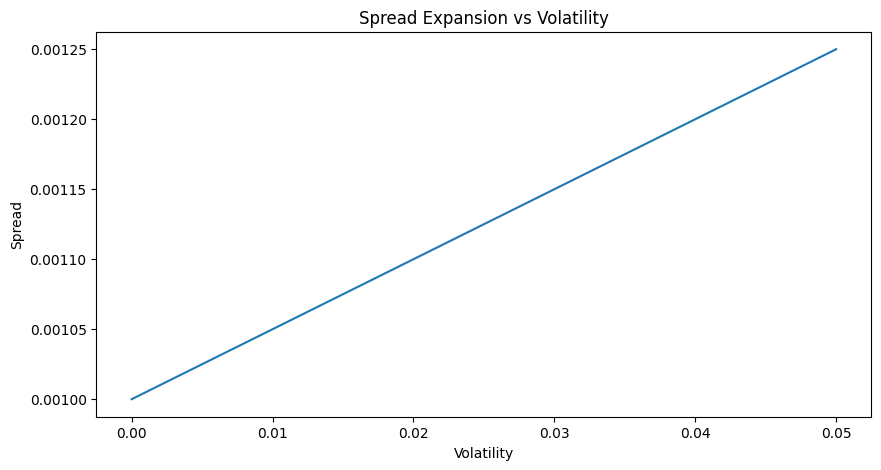

In [5]:
mm = MarketMaker(
    base_spread=0.001,
    inventory_limit=1000,
    risk_aversion=0.5,
    volatility_sensitivity=5.0,
)

vol_levels = np.linspace(0, 0.05, 50)
spreads = [mm.compute_spread(v) for v in vol_levels]

plt.figure(figsize=(10,5))
plt.plot(vol_levels, spreads)
plt.title("Spread Expansion vs Volatility")
plt.xlabel("Volatility")
plt.ylabel("Spread")
plt.show()

## Interpretation — Spread as a Function of Volatility and Risk Compensation

Biểu đồ cho thấy một quan hệ tuyến tính rõ ràng giữa volatility và spread.

Điều này phản ánh trực tiếp cơ chế trong mô hình:

$$ spread = base_spread × (1 + volatility_sensitivity × volatility) $$

Tuy nhiên, ý nghĩa kinh tế của đường thẳng này sâu hơn nhiều so với hình thức tuyến tính đơn giản.

---

### 1. Spread không phải là "chi phí giao dịch" thuần túy

Trong microstructure, spread bao gồm ba thành phần chính:

1) Order processing cost
2) Inventory holding cost
3) Adverse selection cost

Khi volatility tăng:

- Xác suất informed trading tăng
- Sai lệch định giá tạm thời tăng
- Rủi ro định giá sai tăng

Market maker buộc phải mở rộng spread để bù đắp:

> Expected loss from informed traders.

Do đó, spread là premium của risk insurance.

---

### 2. Volatility như một proxy cho Information Asymmetry

Trong mô hình này, volatility được đưa vào ngoại sinh.

Nhưng về bản chất, volatility đại diện cho:

- Uncertainty về giá trị thật
- Information arrival intensity
- Risk of price jumps

Khi volatility tăng:

> Expected adverse move | trade execution tăng.

Market maker không biết client có thông tin hay không,
nên spread tăng như một cơ chế phòng vệ.

---

### 3. Tuyến tính chỉ là bậc một (First-Order Approximation)

Quan hệ tuyến tính trong biểu đồ là một xấp xỉ bậc một.

Trong thực tế:

- Spread thường phi tuyến theo volatility
- Gần regime crisis, spread có thể blow out đột ngột
- Khi volatility vượt ngưỡng, liquidity có thể co rút mạnh

Do đó đường thẳng này nên được hiểu là:

> Local linearization around normal regime.

---

### 4. Spread Widening là cơ chế phòng thủ trước Withdrawal

Trình tự phản ứng hợp lý của market maker là:

Volatility tăng
→ Spread tăng
→ Inventory accumulation chậm lại
→ Nếu vẫn không cân bằng được
→ Withdrawal

Tức là spread widening là lớp bảo vệ thứ nhất.

Withdrawal là lớp bảo vệ cuối cùng.

Biểu đồ này mô tả cơ chế bảo vệ đầu tiên.

---

### 5. Structural Implication

Khi volatility tăng đồng loạt trên thị trường:

- Tất cả market makers widen spread
- Effective liquidity giảm
- Transaction cost tăng
- Price impact tăng

Điều này có thể tạo vòng lặp:

Volatility tăng
→ Spread tăng
→ Market depth giảm
→ Price impact tăng
→ Volatility tăng thêm

Đây là mầm mống của volatility clustering nội sinh.

---

### 6. Liquidity Is State-Dependent

Spread không cố định.

Liquidity không phải một tham số tĩnh.

Liquidity phụ thuộc vào:

> State of uncertainty.

Trong mô hình này, volatility là state variable điều khiển liquidity.

---

### 7. Mathematical Interpretation

Nếu ký hiệu:

$ σ = volatility  $

$ k = volatility_sensitivity  $

thì:

$ d(spread)/dσ = base_spread × k $

Hệ số này đo độ nhạy của liquidity với uncertainty.

Nếu k lớn:

> Hệ thống dễ rơi vào regime spread blowout.

Nếu k nhỏ:

> Market maker chấp nhận rủi ro cao hơn.

Do đó volatility_sensitivity là tham số cấu trúc quan trọng của hệ thống.

---

### Core Concept

Spread là giá của thanh khoản.

Volatility là giá của bất định.

Khi bất định tăng, giá thanh khoản tăng.

Nếu bất định tăng đủ mạnh,
thanh khoản có thể không còn được cung cấp nữa.

## Simulation 3 — Endogenous Liquidity Withdrawal

Bây giờ ta mô phỏng tình huống cực đoan hơn:

- Volatility cao
- Order flow một chiều
- Inventory tăng nhanh

Mục tiêu là quan sát khi nào market maker trở nên inactive.

In [6]:
np.random.seed(1)

mm = MarketMaker(
    base_spread=0.001,
    inventory_limit=300,
    risk_aversion=1.0,
    volatility_sensitivity=10.0,
)

mid_price = 100
volatility = 0.03

inventory_path = []
spread_path = []

for t in range(200):

    quotes = mm.quote(mid_price, volatility)

    if not mm.active:
        print(f"Liquidity withdrawn at step {t}")
        break

    trade_price = quotes["ask"]
    mm.execute_trade(trade_price, quantity=15, side="buy")

    inventory_path.append(mm.inventory)
    spread_path.append(mm.compute_spread(volatility))

Liquidity withdrawn at step 21


## Interpretation — Endogenous Liquidity Withdrawal at Step 21

Thông báo:

> Liquidity withdrawn at step 21

không phải là một sự kiện ngẫu nhiên. Nó là kết quả tất yếu của cơ chế động học inventory trong hệ thống.

---

### 1. Cơ chế toán học phía sau

Mỗi bước:

- Client mua 15 units
- Market maker bán ra 15 units
- Inventory giảm 15

Do đó:

$ Inventory_t = -15 × t $

Với inventory_limit = 300: $ |Inventory| = 300 khi t ≈ 20 $

Vì vậy tại bước 21:

> |Inventory| > inventory_limit

→ active = False
→ market maker withdraw.

Đây là một boundary hitting problem.

Inventory drift tuyến tính chạm một absorbing barrier.

---

### 2. Ý nghĩa cấu trúc

Liquidity không biến mất do:

- Không có người giao dịch
- Hay do spread quá rộng

Nó biến mất vì:

> Risk constraint bị vi phạm.

Điều này rất quan trọng:

Liquidity là một hàm của balance sheet capacity.

Khi capacity đạt giới hạn:

> Thanh khoản dừng lại ngay lập tức.

---

### 3. Sudden Phase Transition

Từ step 0 đến step 20:

- Market hoạt động bình thường
- Quotes vẫn tồn tại
- Spread không thay đổi đáng kể

Tại step 21:

> Hệ thống chuyển trạng thái từ "liquid" sang "illiquid"

Chuyển đổi này xảy ra trong một bước thời gian duy nhất.

Đây là một dạng phase transition rời rạc.

---

### 4. Hidden Fragility Accumulation

Từ góc nhìn bên ngoài:

- Không có tín hiệu cảnh báo mạnh
- Giá chưa sụp đổ
- Spread chưa blow out

Nhưng inventory đã tích tụ rủi ro dần dần.

Rủi ro này là latent.

Khi vượt ngưỡng, hệ thống không còn hấp thụ shock.

---

### 5. Microstructure Interpretation

Market maker đóng vai trò:

> Buffer giữa order flow và giá.

Trong 20 bước đầu:

Order flow imbalance được hấp thụ hoàn toàn.

Tại bước 21: Buffer đầy.

Kể từ đó:

> Shock không còn bị hấp thụ,
mà truyền trực tiếp vào giá.

---

### 6. Bridge to Systemic Instability

Nếu ta thêm vào hệ thống:

- Leverage
- Margin call
- Forced liquidation

thì withdrawal của market maker sẽ:

→ Làm depth giảm mạnh
→ Tăng price impact
→ Kích hoạt liquidation
→ Tăng sell pressure

Tạo thành feedback loop.

Step 21 trong mô hình đơn giản này là điểm bắt đầu của fragility.

---

### 7. Conceptual Takeaway

Liquidity withdrawal là endogenous.

Không cần shock ngoại sinh lớn.

Chỉ cần:

> Persistent order imbalance + Finite inventory capacity

là đủ để thị trường mất thanh khoản. Đây là nền tảng cho crash dynamics nội sinh.

## From Inventory Risk to Systemic Fragility

Chuỗi logic của project:

Price formation
→ Liquidity depth
→ Inventory risk
→ Liquidity withdrawal
→ Structural fragility

Notebook 04 sẽ tiếp tục bằng cách đưa leverage vào hệ thống.
Khi liquidation xuất hiện cùng lúc với withdrawal,
feedback loop sẽ tạo ra crash nội sinh.